# POWDER OTA versus ray-traced channel estimates: EBC ↔ Guest House

**[FACT — scope]** Compare the stored complex channel estimates in [CAAI-FAU/Key-Generation](https://huggingface.co/datasets/CAAI-FAU/Key-Generation), configuration **CaST-Powder-OTA-Dense-Nodes-123**, with fresh snapshots from this block's [production backend](../python/rt_channel_emulation/backend.py). Use the supplied scene coordinates for node **1 (EBC)** and node **2 (Guest House)**; keep the two transmission directions separate. Node 3's records are not used.

**[FACT — inspected revision]** The pinned revision below contains 97 detected 1→2 records and 98 detected 2→1 records, each with 16 complex taps spaced 1 µs apart. The notebook reads and validates these quantities instead of assuming the counts.

**[INFERENCE — comparison boundary; high confidence]** Normalized magnitude/power shape is the defensible starting point: the exported columns do not specify calibrated radio/antenna gains or a shared absolute phase/time reference. Shape agreement is **not** evidence of absolute path-loss, phase, or time-of-flight accuracy.

```text
Hugging Face → select tx/rx → I + jQ → validate stored delays ──────┐
POWDER scene + node positions → production backend → same L, Fs ──┤
                                                                ↓
                         normalize each tap vector to unit energy
                                                                ↓
                          tap-magnitude plots + per-record shape errors
```


## 1. Install optional notebook tools and select the kernel

**[FACT — procedure]** First follow [README](../README.md) to install the block and configure LLVM if needed. From the repository root:

```bash
.venv/bin/python -m pip install -e ".[profiling,ota]"
.venv/bin/hf auth login
```

Open this notebook with the project's **.venv Python** and run cells in order. Skip login if already authenticated. Access to this repository requires an authorized Hugging Face account; do not paste tokens into the notebook. The Hub client downloads only the selected Parquet file; PyArrow reads it. Matplotlib, the kernel, and NBClient reuse the existing profiling extra. No GNU Radio flowgraph or map GUI is launched.

Sources: [Hub authentication](https://huggingface.co/docs/huggingface_hub/quick-start#authentication), [versioned downloads](https://huggingface.co/docs/huggingface_hub/guides/download), [Parquet reader](https://arrow.apache.org/docs/python/generated/pyarrow.parquet.read_table.html).


In [16]:
import os
import sys

print("Python:", sys.executable)
print("Dr.Jit already loaded:", "drjit" in sys.modules)

os.environ["DRJIT_LIBLLVM_PATH"] = (
    "/opt/local/libexec/llvm-18/lib/libLLVM.dylib"
)

import drjit as dr

print("LLVM active:", bool(dr.has_backend(dr.JitBackend.LLVM)))

from sionna.rt import PathSolver
print("Sionna import: OK")



Python: /Users/josea/Workspaces/gr-RT_channel_emulation/.venv/bin/python
Dr.Jit already loaded: True
LLVM active: True
Sionna import: OK


In [17]:
from dataclasses import asdict
from datetime import datetime, timezone
from hashlib import sha256
from importlib.metadata import version
import json
import os

# If required, set the LLVM path BEFORE the backend's first Sionna import.
# os.environ["DRJIT_LIBLLVM_PATH"] = "/opt/local/libexec/llvm-18/lib/libLLVM.dylib"
os.environ["DRJIT_LIBLLVM_PATH"] = (
    "/opt/local/libexec/llvm-18/lib/libLLVM.dylib"
)
from pathlib import Path
import sys

import numpy as np
from huggingface_hub import hf_hub_download
import pyarrow.parquet as pq
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

from rt_channel_emulation.backend import SimulationConfig, SionnaRTChannelBackend
import rt_channel_emulation.backend as backend_module

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").is_file():
    ROOT = ROOT.parent
if not (ROOT / "python/rt_channel_emulation/backend.py").is_file():
    raise RuntimeError("Start the notebook in the repository root or tests/.")
print("Python:", sys.executable)
print("Backend:", backend_module.__file__)


Python: /Users/josea/Workspaces/gr-RT_channel_emulation/.venv/bin/python
Backend: /Users/josea/Workspaces/gr-RT_channel_emulation/python/rt_channel_emulation/backend.py


## 2. State the experimental assumptions

**[FACT — coordinate input]** Positions below are the user's XYZ coordinates in the loaded POWDER scene, in metres. Z is a scene coordinate, **not** height above local terrain. No geographic conversion or coordinate adjustment is applied.

**[INFERENCE — provisional RF frequency; medium confidence]** The local CaST acquisition profile specifies 3.5 GHz, but the Hugging Face export has no frequency column or acquisition attributes. The default below is therefore **unconfirmed for this capture**. Confirm it against the experiment configuration before reporting a physical model comparison. Source inspected: local `Powder/PowderKeyGen/orch/DataCollectionKeyGeneration.py`, `PIDML_CAST_PROFILE`. Change both the value and its provenance note when confirmed.

**[INFERENCE — antenna assumption; low confidence as an OTA match]** Isotropic, vertically polarized antennas are an explicit simulation baseline, not a verified description of the installed radios. The dataset does not supply measured antenna patterns, orientation, gain calibration, or an acquisition-code version.

**[FACT — RT settings]** Maximum depth defaults to 5, matching the block. The production backend enables LoS, specular reflections and refraction; disables diffuse reflection; and requests unnormalized tap amplitudes with normalized path delays. The notebook does not override these propagation algorithms or add signal gain/noise. The tap count and sampling rate are obtained from OTA metadata.


In [18]:
REPO_ID = "CAAI-FAU/Key-Generation"
DATASET_NAME = "CaST-Powder-OTA-Dense-Nodes-123"
REVISION = "d9c1759b67e5cc45d378a069b152c393b1a4f5d5"  # Pin the inspected dataset.
FILENAME = f"{DATASET_NAME}/train-00000-of-00001.parquet"
RESULTS_ROOT = ROOT / "tests/ota_comparison_results"
CACHE_DIR = RESULTS_ROOT / "cache"
LOCAL_PARQUET = None  # Optional: Path to an already downloaded copy of this file.

CARRIER_FREQUENCY_HZ = 3.5e9
FREQUENCY_NOTE = "Unconfirmed for this capture; default from local PIDML_CAST_PROFILE."
MAX_DEPTH = 15
SEED = 42
ANTENNA_PATTERN = "iso"
POLARIZATION = "V"
NODES = {
    1: {"name": "EBC", "position": (59.391, -174.7, 13.632)},
    2: {"name": "Guest House", "position": (230.06, -116.5, 2.9765)},
    3: {"name": "Moran", "position": (8.449, 151.12, 4.7896)},
    4: {"name": "USTAR", "position": (-147.4, -15.07, 2.2198)},
}
LINKS = ((1, 2), (2, 1))
print("RF frequency:", CARRIER_FREQUENCY_HZ / 1e9, "GHz —", FREQUENCY_NOTE)
print("Node separation:", np.linalg.norm(
    np.subtract(NODES[1]["position"], NODES[2]["position"])), "m")


RF frequency: 3.5 GHz — Unconfirmed for this capture; default from local PIDML_CAST_PROFILE.
Node separation: 180.63412535080408 m


## 3. Load and validate the recorded link estimates

**[FACT — field definitions]** `tx` and `rx` identify direction; `taps_I` and `taps_Q` form \(h[k]=I[k]+jQ[k]\). A tap is one coefficient of a sampled channel impulse response, not necessarily one physical ray. `tap_delays_s` provides the delay grid. The `channel` field is a link label, **not RF frequency**. These names and types were checked in the pinned Parquet file.

**[FACT — selection rule]** Use every detected record for each requested direction, sorted by timestamp; report excluded undetected records. Fail on absent links, inconsistent node names, nonfinite values, unequal tap lengths, nonuniform/different delay grids, or zero-energy detected estimates. Do not trim outliers or choose only the best-looking snapshots.

**[FACT — estimator distinction]** The inspected local acquisition function `estimate_cast_probe_channel()` returns an energy-normalized **matched-filter** response, not the LS estimator used by this repository's demo. For \(y=x*h+n\), correlating with the known probe gives \(r_{yx}/E_x=h*(r_{xx}/E_x)+r_{nx}/E_x\); finite-probe autocorrelation and noise therefore affect the stored estimates. The exact capture-code revision is not in the export. This notebook compares the **stored estimates**, without silently calling them ideal propagation taps.

Source inspected: local `Powder/PowderKeyGen/network/RX/cast_probe.py` (`_matched_filter_taps`). Background: [original CaST estimator](https://github.com/wineslab/cast/blob/main/radio_api/channel-estimate.py). The original script and the local acquisition implementation are not asserted to be identical.


In [19]:
if LOCAL_PARQUET is None:
    parquet_path = Path(hf_hub_download(
        repo_id=REPO_ID, filename=FILENAME, repo_type="dataset",
        revision=REVISION, cache_dir=str(CACHE_DIR), token=True,
    ))
else:
    parquet_path = Path(LOCAL_PARQUET).expanduser().resolve()
    print("Local-file mode: verify this file's origin; its SHA-256 will be saved.")

# Read only taps and selection metadata, not the much larger raw IQ columns.
columns = ["tx", "rx", "tx_name", "rx_name", "detected", "ids", "timestamp",
           "taps_I", "taps_Q", "tap_delays_s"]
records = pq.read_table(parquet_path, columns=columns).to_pylist()
print("Downloaded/read rows:", len(records))
print("Data SHA-256:", sha256(parquet_path.read_bytes()).hexdigest())


Downloaded/read rows: 390
Data SHA-256: d113a987fda342313f6d270421f843d449ea993b8ee076e2971574d6c0359edc


In [20]:
def select_link(records, tx_id, rx_id):
    """Return one direction's complex taps [records, taps], delay grid, and audit.

    Input: Parquet rows with explicit TX/RX IDs and stored tap delays in seconds.
    Output: validated arrays in timestamp order; undetected records are counted,
    not used as zero-valued channel measurements. Invalid detected rows fail.
    """
    selected = [(i, row) for i, row in enumerate(records)
                if (row["tx"], row["rx"]) == (tx_id, rx_id)]
    if not selected:
        raise ValueError(f"No records for {tx_id}->{rx_id}.")
    expected_names = (NODES[tx_id]["name"], NODES[rx_id]["name"])
    if any((row["tx_name"], row["rx_name"]) != expected_names for _, row in selected):
        raise ValueError("Stored node names disagree with the configured node IDs.")
    valid = [(i, row) for i, row in selected if row["detected"]]
    if not valid:
        raise ValueError(f"No detected records for {tx_id}->{rx_id}.")
    valid.sort(key=lambda item: (item[1]["timestamp"], item[0]))
    i_values = np.asarray([row["taps_I"] for _, row in valid], dtype=float)
    q_values = np.asarray([row["taps_Q"] for _, row in valid], dtype=float)
    delays = np.asarray([row["tap_delays_s"] for _, row in valid], dtype=float)
    timestamps = np.asarray([row["timestamp"] for _, row in valid], dtype=float)
    if i_values.ndim != 2 or i_values.shape != q_values.shape or delays.shape != i_values.shape:
        raise ValueError("I, Q and delay arrays must have the same [records, taps] shape.")
    if i_values.shape[1] < 2:
        raise ValueError("At least two delays are needed to determine tap spacing.")
    taps = i_values + 1j * q_values
    if not (np.isfinite(taps).all() and np.isfinite(delays).all()
            and np.isfinite(timestamps).all()):
        raise ValueError("Non-finite tap, delay, or timestamp.")
    if np.any(np.sum(np.abs(taps)**2, axis=1) <= 0):
        raise ValueError("A detected estimate has zero energy; cannot normalize it.")
    spacing_s = float(delays[0, 1] - delays[0, 0])
    expected = np.arange(taps.shape[1]) * spacing_s
    # The stored delays are float32, so allow small representation error.
    if spacing_s <= 0 or not np.allclose(delays, expected[None, :], rtol=1e-5, atol=1e-12):
        raise ValueError("All delay grids must start at zero and be uniformly spaced.")
    return {
        "taps": taps, "delays_s": delays[0], "sample_rate_hz": 1.0 / spacing_s,
        "timestamps": timestamps,
        "dataset_rows": np.asarray([i for i, _ in valid]),
        "record_ids": np.asarray([row["ids"] for _, row in valid]),
        "selected": len(selected), "used": len(valid),
        "excluded_undetected": len(selected) - len(valid),
    }


In [21]:
ota = {pair: select_link(records, *pair) for pair in LINKS}
for (tx, rx), data in ota.items():
    # Round to Hz only to remove float32 timestamp-grid representation error.
    data["sample_rate_hz"] = float(round(data["sample_rate_hz"]))
    print(f"{tx}->{rx}: {data['used']}/{data['selected']} records used, "
          f"{data['excluded_undetected']} undetected excluded; "
          f"{data['taps'].shape[1]} taps, {data['sample_rate_hz']:g} samples/s")


1->2: 97/97 records used, 0 undetected excluded; 16 taps, 1e+06 samples/s
2->1: 98/98 records used, 0 undetected excluded; 16 taps, 1e+06 samples/s


## 4. Calculate the block's RT reference

**[FACT — calculation]** Call `SionnaRTChannelBackend.compute_snapshot()` once per direction. The reference has exactly the OTA tap count \(L\), sampling rate \(F_s=1/\Delta\tau\), and lags 0…\(L-1\). For these data, \(L=16\) and \(F_s=1\) MS/s. This is the same tap-generation path used by the GNU Radio block, without its streaming scheduler.

**[FACT — delay convention]** The production backend sets `normalize_delays=True`, placing the earliest traced path at zero before sampling. The local acquisition estimator detects a correlation peak and starts the stored window there. They are relative-delay conventions, not an absolute shared time-of-flight reference. No shifting, interpolation, peak fitting, or circular wrapping is performed here. The next cell checks whether all strongest taps occur at bin zero; otherwise it stops and requests an explicit alignment decision.

**[INFERENCE — alignment limitation; high confidence]** Matching strongest-tap bins is only a coarse alignment check. It does not prove equal fractional timing or that the strongest OTA component is the first physical arrival. Nor does 1 µs tap spacing prove that the analog filters match Sionna's ideal bandwidth model.

Sources: [backend](../python/rt_channel_emulation/backend.py), [Sionna tap definition and delay normalization](https://nvlabs.github.io/sionna/rt/api/paths.html#sionna.rt.Paths.taps).


In [22]:
backend = SionnaRTChannelBackend()
rt = {}
configs = {}
try:
    for tx, rx in LINKS:
        data = ota[(tx, rx)]
        config = SimulationConfig(
            scene_path="POWDER",
            tx_position=NODES[tx]["position"], rx_position=NODES[rx]["position"],
            sample_rate=data["sample_rate_hz"],
            carrier_frequency_hz=CARRIER_FREQUENCY_HZ,
            max_depth=MAX_DEPTH, l_min=0, l_max=data["taps"].shape[1] - 1,
            tx_pattern=ANTENNA_PATTERN, rx_pattern=ANTENNA_PATTERN,
            tx_polarization=POLARIZATION, rx_polarization=POLARIZATION,
            seed=SEED, visualize=False,
        )
        snapshot = backend.compute_snapshot(config)
        taps = np.asarray(snapshot.taps, dtype=np.complex128)
        if taps.shape != (data["taps"].shape[1],) or not np.isfinite(taps).all():
            raise ValueError("RT tap length or finite-value validation failed.")
        if not snapshot.has_paths or np.linalg.norm(taps) == 0:
            raise ValueError(f"No nonzero RT reference for {tx}->{rx}; do not invent a normalized profile.")
        if np.argmax(np.abs(taps)) != 0 or np.any(np.argmax(np.abs(data["taps"]), axis=1) != 0):
            raise ValueError("Strongest taps are not all at bin zero. Review delay alignment explicitly.")
        rt[(tx, rx)] = taps
        configs[(tx, rx)] = asdict(config)
        scene_path = Path(snapshot.resolved_scene_path)
        print(f"{tx}->{rx}: {len(taps)} RT taps; ||h_RT||₂ = {np.linalg.norm(taps):.6g}")
finally:
    backend.close()


2026-09-17 11:20:07 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
1->2: 16 RT taps; ||h_RT||₂ = 4.34207e-05
2026-09-17 11:20:08 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
2->1: 16 RT taps; ||h_RT||₂ = 4.41754e-05


## 5. Compare shape, without hiding the normalization

**[FACT — definitions]** For record \(i\), let \(h_i[k]\) be its stored complex taps and \(g[k]\) the RT reference. Define unit-energy magnitude \(a_i[k]=|h_i[k]|/\sqrt{\sum_k|h_i[k]|^2}\) and \(b[k]=|g[k]|/\sqrt{\sum_k|g[k]|^2}\).

- **Normalized PDP:** \(p_i[k]=a_i[k]^2\), \(q[k]=b[k]^2\). Each sums to 1; these are fractions of recorded tap energy, **not watts or dBm**.
- **Magnitude-shape NMSE:** \(\sum_k(a_i[k]-b[k])^2/\sum_k a_i[k]^2=\sum_k(a_i[k]-b[k])^2\). Zero is a perfect shape match; the range is 0…2. This ignores complex phase.
- **PDP total-variation distance:** \(\tfrac12\sum_k|p_i[k]-q[k]|\), ranging from 0 (equal) to 1 (disjoint energy profiles).
- **Plotted OTA profile:** \(\bar p[k]=\frac1M\sum_i p_i[k]\); plot \(\sqrt{\bar p[k]}\) as the RMS unit-energy tap magnitude. Average **linear power**, not dB values or unaligned complex coefficients.

**[FACT — example]** Taps \([2,1]\) give \(p=[0.8,0.2]\). Taps \([20j,10j]\) have the same normalized shape and zero shape error, despite different gain and phase. Thus a good score here cannot establish absolute calibration.

**[INFERENCE — limitations; high confidence]** Residual errors combine scene/material/antenna mismatch, estimator sidelobes, receiver filtering, noise, residual synchronization errors, and actual environmental variation. The static RT snapshot does not model the capture's temporal variation. No noise floor is subtracted and no parameters are optimized against these records.

Sources: [NumPy vector norms](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html), the explicit formulas above, and [Sionna propagation model](https://nvlabs.github.io/sionna/rt/em_primer.html).


In [39]:
def compare_taps(measured, reference):
    """Compare [M, L] measured taps with one [L] reference, without delay fitting.

    Returns unit-energy PDPs, their arithmetic mean, and one error per record.
    Global gain and phase are intentionally discarded; raw taps remain unchanged.
    """
    measured = np.asarray(measured, dtype=np.complex128)
    reference = np.asarray(reference, dtype=np.complex128)
    if measured.ndim != 2 or measured.shape[0] == 0 or reference.shape != (measured.shape[1],):
        raise ValueError("Expected nonempty [records, taps] and matching [taps] arrays.")
    if not (np.isfinite(measured).all() and np.isfinite(reference).all()):
        raise ValueError("Taps must be finite.")
    measured_energy = np.sum(np.abs(measured)**2, axis=1, keepdims=True)
    reference_energy = np.sum(np.abs(reference)**2)
    if np.any(measured_energy <= 0) or reference_energy <= 0:
        raise ValueError("Zero-energy channels cannot be normalized.")
    p = np.abs(measured)**2 / measured_energy
    q = np.abs(reference)**2 / reference_energy
    magnitude_measured = np.abs(measured)
    print("magnitude_measured:", magnitude_measured)
    magnitude_reference = np.abs(reference)
    print("magnitude_reference:", magnitude_reference)
    return {
        "ota_pdp": p, "rt_pdp": q, "mean_ota_pdp": p.mean(axis=0),
        "magnitude_nmse": np.sum((np.sqrt(p) - np.sqrt(q))**2, axis=1),
        "pdp_tv": 0.5 * np.sum(np.abs(p - q), axis=1),
        "ota_taps": magnitude_measured, "rt_taps": magnitude_reference, "mean_ota_taps": magnitude_measured.mean(axis=0),
    }


In [40]:
comparison = {pair: compare_taps(ota[pair]["taps"], rt[pair]) for pair in LINKS}
summary = []
for tx, rx in LINKS:
    data, result = ota[(tx, rx)], comparison[(tx, rx)]
    row = {
        "tx": tx, "rx": rx, "tx_name": NODES[tx]["name"], "rx_name": NODES[rx]["name"],
        "records_selected": data["selected"], "records_used": data["used"],
        "excluded_undetected": data["excluded_undetected"],
        "tap_count": data["taps"].shape[1], "sample_rate_hz": data["sample_rate_hz"],
        "mean_magnitude_nmse": float(result["magnitude_nmse"].mean()),
        "mean_pdp_tv": float(result["pdp_tv"].mean()),
        "ota_norm_mean_uncalibrated": float(np.linalg.norm(data["taps"], axis=1).mean()),
        "rt_norm": float(np.linalg.norm(rt[(tx, rx)])),
    }
    summary.append(row)
    print(f"{row['tx_name']} -> {row['rx_name']} (n={row['records_used']}): "
          f"mean magnitude-shape NMSE={row['mean_magnitude_nmse']:.5f}, "
          f"mean PDP TV={row['mean_pdp_tv']:.5f}")
print("Shape-only results. RF provenance:", FREQUENCY_NOTE)


magnitude_measured: [[0.10052971 0.00355229 0.01394948 ... 0.00359056 0.00460466 0.01424779]
 [0.10767758 0.00377292 0.0089295  ... 0.01218922 0.01067035 0.0105539 ]
 [0.10336482 0.01079601 0.01360573 ... 0.00589747 0.00476204 0.00294662]
 ...
 [0.10407019 0.01076586 0.01011509 ... 0.00303011 0.00394691 0.00324793]
 [0.11852229 0.00800672 0.0039194  ... 0.00544244 0.0040727  0.01035927]
 [0.11290619 0.01462583 0.00869592 ... 0.00094367 0.00647912 0.01200808]]
magnitude_reference: [4.32079843e-05 1.99636864e-06 3.64776921e-06 8.09642621e-07
 4.78271922e-07 2.95999443e-07 2.20266706e-07 1.75997550e-07
 1.46696167e-07 1.25813663e-07 1.10162159e-07 9.79862087e-08
 8.82378276e-08 8.02588907e-08 7.36075230e-08 6.79728990e-08]
magnitude_measured: [[0.09251599 0.00707431 0.00949347 ... 0.00522905 0.00751477 0.00322038]
 [0.12106868 0.00531953 0.0077204  ... 0.00698296 0.00680279 0.00175465]
 [0.10360808 0.01119791 0.00329594 ... 0.00107863 0.0017426  0.00864892]
 ...
 [0.11701036 0.00665646 0.

## 6. Compare tap magnitudes

**[FACT — plot definitions]** Blue shows OTA; red shows RT. The two stem plots compare unit-energy tap magnitudes for EBC→Guest House and Guest House→EBC. The legends identify only the traces; record counts remain in the numerical summary. Blue vertical ranges span the 5th–95th percentiles across individual OTA records; they describe observed variability, **not confidence intervals**. The horizontal axis is the recorded relative delay in microseconds.


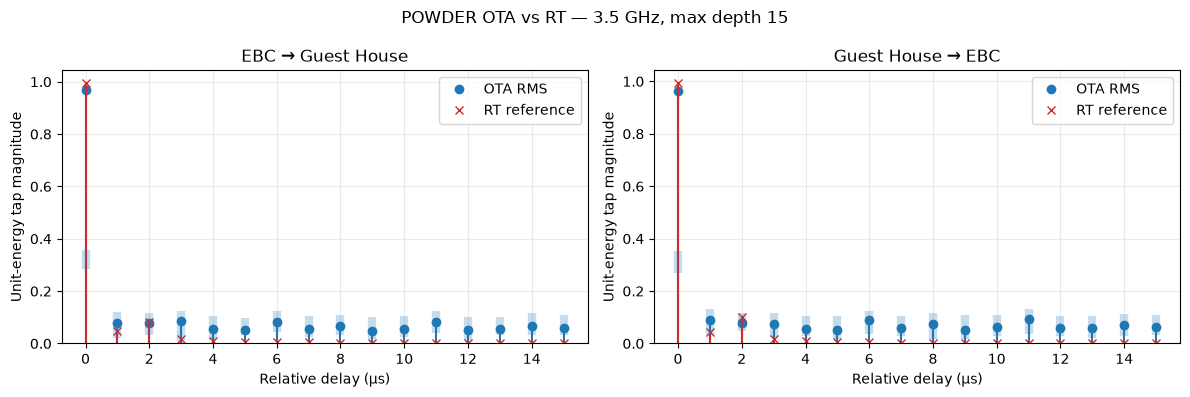

In [43]:
fig, axes = plt.subplots(1, len(LINKS), figsize=(12, 4), sharex=True, squeeze=False)
for column, (tx, rx) in enumerate(LINKS):
    data, result = ota[(tx, rx)], comparison[(tx, rx)]
    delay_us = data["delays_s"] * 1e6
    mean_p, q = result["mean_ota_pdp"], result["rt_pdp"]
    # mean_p, q = result["mean_ota_taps"], result["rt_taps"]
    # Escalate q to match the OTA RMS magnitude for visual comparison, since the OTA RMS is not calibrated to the RT reference.
    # q *= np.linalg.norm(mean_p) / np.linalg.norm(q)
    # low, high = np.quantile(result["ota_pdp"], [0.05, 0.95], axis=0)
    low, high = np.quantile(result["ota_taps"], [0.00, 0.95], axis=0)
    ax = axes[0, column]
    for values, color, marker, label in (
        (np.sqrt(mean_p), "tab:blue", "o", "OTA RMS"),
        (np.sqrt(q), "tab:red", "x", "RT reference"),
    ):
        artists = ax.stem(delay_us, values, linefmt=color, markerfmt=marker, basefmt=" ")
        artists.markerline.set_color(color)
        artists.markerline.set_label(label)
    ax.vlines(delay_us, np.sqrt(low), np.sqrt(high), color="tab:blue", alpha=0.25, linewidth=6)
    ax.set_title(f"{NODES[tx]['name']} → {NODES[rx]['name']}")
    ax.set_ylabel("Unit-energy tap magnitude")
    ax.set_xlabel("Relative delay (µs)")
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(alpha=0.25)
    ax.set_xticks(delay_us[::2])
fig.suptitle(f"POWDER OTA vs RT — {CARRIER_FREQUENCY_HZ/1e9:g} GHz, max depth {MAX_DEPTH}", fontsize=12)
fig.tight_layout()
plt.show()


## 7. Save an auditable local result

**[FACT — outputs]** Each run gets a new UTC-named directory under `tests/ota_comparison_results/` (ignored by Git). Save the figure, raw/normalized arrays and per-record metrics in NPZ, plus JSON containing row counts, the dataset revision/file hash, radio settings, coordinates, library versions, and backend/scene-XML hashes. The XML hash does **not** fingerprint all referenced mesh assets; retain the scene directory with any archived experiment.

**[FACT — local-copy caveat]** When `LOCAL_PARQUET` is used, the saved hash identifies the file but the notebook does not assert it came from the configured Hub revision. No data is uploaded or modified on Hugging Face.


In [26]:
run_dir = RESULTS_ROOT / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
run_dir.mkdir(parents=True, exist_ok=False)
fig.savefig(run_dir / "ota_vs_rt_taps.png", dpi=180)
arrays = {}
for tx, rx in LINKS:
    key = f"{tx}_to_{rx}"
    data, result = ota[(tx, rx)], comparison[(tx, rx)]
    arrays.update({
        f"{key}_ota_taps": data["taps"], f"{key}_rt_taps": rt[(tx, rx)],
        f"{key}_delays_s": data["delays_s"], f"{key}_timestamps": data["timestamps"],
        f"{key}_dataset_rows": data["dataset_rows"], f"{key}_record_ids": data["record_ids"],
        f"{key}_ota_pdp": result["ota_pdp"], f"{key}_rt_pdp": result["rt_pdp"],
        f"{key}_magnitude_nmse": result["magnitude_nmse"], f"{key}_pdp_tv": result["pdp_tv"],
    })
np.savez_compressed(run_dir / "comparison.npz", **arrays)
report = {
    "dataset": {
        "repo_id": REPO_ID, "configuration": DATASET_NAME, "configured_revision": REVISION,
        "filename": FILENAME, "source": "local_file" if LOCAL_PARQUET is not None else "huggingface",
        "local_path": str(parquet_path), "sha256": sha256(parquet_path.read_bytes()).hexdigest(),
        "rows_in_file": len(records),
    },
    "frequency_note": FREQUENCY_NOTE,
    "comparison": "Unit-energy magnitudes/PDP; no time shifts or absolute gain/phase calibration.",
    "antenna_assumption": "Isotropic V-polarized baseline; not calibrated to installed antennas.",
    "configs": {f"{tx}_to_{rx}": configs[(tx, rx)] for tx, rx in LINKS},
    "versions": {name: version(name) for name in
                 ("rt-channel-emulation", "sionna-rt", "drjit", "mitsuba", "numpy",
                  "matplotlib", "huggingface-hub", "pyarrow")},
    "backend_sha256": sha256(Path(backend_module.__file__).read_bytes()).hexdigest(),
    "scene_xml": str(scene_path), "scene_xml_sha256": sha256(scene_path.read_bytes()).hexdigest(),
    "summary": summary,
}
(run_dir / "summary.json").write_text(json.dumps(report, indent=2, allow_nan=False) + "\n")
print("Saved:", run_dir)


Saved: /Users/josea/Workspaces/gr-RT_channel_emulation/tests/ota_comparison_results/20260917T152008_517272Z


## Conclusion

**[FACT — what the notebook establishes]** It compares all valid stored EBC↔Guest House estimates with the block's actual POWDER tap generator on the same 16-bin, 1 µs delay grid, retaining separate direction counts and repeatable data/settings. The output quantifies **normalized shape discrepancy**.

**[INFERENCE — interpretation; high confidence]** Low shape error alone cannot validate the environmental model: coarse delay resolution and a dominant first tap can make different propagation mechanisms look similar. Confirm the RF frequency, scene/antenna registration, measured antenna patterns and gain/filter/timing calibration; account for the acquisition estimator before making claims about absolute channel accuracy. Do not describe these scores as an OTA validation of ideal LS taps or calibrated path loss.
